In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


hello


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

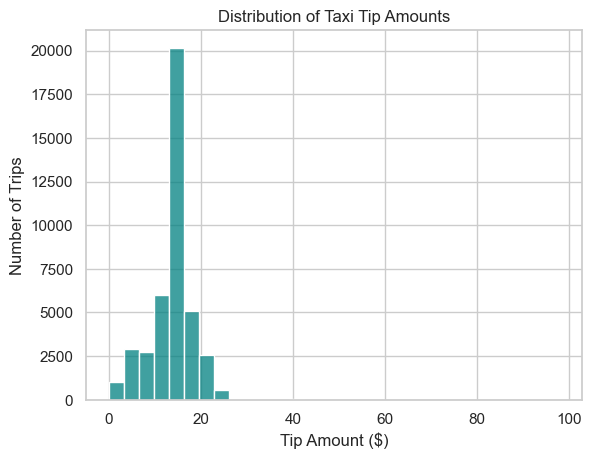

In [ ]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
display(taxi.shape)
display(taxi.head())
taxi.info()

# - taxi.describe()
display(taxi.describe())
# - count missing values per column: taxi.isna().sum()

display(taxi.isna().sum())


# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(data=taxi, x="tip_amount", color="teal", bins=30)

plt.xlabel("Tip Amount ($)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Tip Amounts")

plt.show()

**Student Reasoning** — Taxi data exploration 

What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

**Answer**: The dataset contains many taxi trips, with each row representing one trip and each column representing a feature such as fare amount, trip distance, and tip amount. There are no obvious missing values based on the initial inspection. The tip_amount variable is right-skewed, with most tips between approximately $5 and $20 and a few unusually large tips creating a long right tail. These outliers and the skewed distribution suggest that preprocessing should include checking for invalid values, handling outliers, and feature scaling before training machine learning models.

In [19]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()

# Remove impossible values
taxi = taxi[
    (taxi["trip_distance"] > 0) &
    (taxi["fare_amount"] > 0) &
    (taxi["tip_amount"] >= 0)
]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# Feature engineering
taxi["fare_per_mile"] = (
    taxi["fare_amount"] / taxi["trip_distance"]
)

taxi["total_surcharge"] = (
    taxi["mta_tax"] +
    taxi["tolls_amount"] +
    taxi["improvement_surcharge"]
)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# One-hot encode categorical variables
taxi = pd.get_dummies(
    taxi,
    columns=[
        "VendorID",
        "RatecodeID",
        "payment_type",
        "store_and_fwd_flag"
    ],
    drop_first=True
)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

**Student Reasoning** — Taxi preprocessing 

1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

**Answer**: 
1. I first checked the dataset for missing values using isnull().sum(). Any rows with missing values were removed using dropna() to ensure the model was trained on complete data and that was ensured when I displayed display(taxi.isna().sum()). I also removed invalid records where trip_distance <= 0, fare_amount <= 0, or tip_amount < 0, since these values are unrealistic for taxi trips and could negatively affect the model's performance and accuracy.

2. I created fare_per_mile. This feature represents how much the passenger was charged per mile traveled. It may capture pricing patterns better than using fare amount or trip distance alone. I also created, total_surcharge by summing mta_tax, tolls_amount, and improvement_surcharge. This combines all additional charges into a single feature, which may help the model better understand the total cost of a trip. Importantly, I did not create any features using tip_amount because it is the target variable and doing so would cause data leakage.

3. I used StandardScaler to standardize the numerical features. StandardScaler transforms each feature so that it has a mean of 0 and a standard deviation of 1. This is appropriate because the numerical features (such as fare_amount, trip_distance, and fare_per_mile) have very different ranges. Scaling ensures that no single feature dominates the others due to its larger magnitude and can improve the performance of many machine learning algorithms. To avoid data leakage, the scaler was fitted only on the training data and then applied to the test data.

In [ ]:
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Second split: 75% of the remaining data for training, 25% for validation
# This gives 60% train, 20% validation, 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE
)

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

# Scale numeric features
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])